# Predicción del precio de vuelos - Leticia Marticorena

El objetivo es desarrollar un modelo predictivo capaz de estimar el precio de un boleto de avión basándonos en diversas características del vuelo. Este problema representa un escenario común en la industria de viajes, donde las aerolíneas y las agencias de viajes buscan ofrecer a los pasajeros tarifas competitivas y precisas.

Con este trabajo queremos ofrecer a los clientes una herramienta que les permita obtener estimaciones precisas del precio de los boletos de avión para su próximo viaje. Sin embargo, el precio de un boleto de avión puede variar significativamente según múltiples factores, como la aerolínea, el destino, la temporada, la clase de servicio y la anticipación de la reserva. Usaremos los archivos **business.csv** y **economy.csv**.

### 1. Descripción del problema de negocio y la metodología a seguir.

Para abordar el problema de predicción del precio de vuelos se adoptó la **metodología CRISP-DM**, la cual estructura el desarrollo de proyectos de Data Science en seis fases iterativas: comprensión del negocio, comprensión de los datos, preparación de los datos, modelamiento, evaluación y despliegue.

**1. Business Understanding (Comprensión del negocio):**
Una agencia de viajes en línea requiere estimar de forma anticipada el precio de pasajes de avión, con el fin de ofrecer un servicio eficiente a los clientes, entregar precios competitivos y aumentar los ingresos por ventas.
El precio de un vuelo depende de múltiples factores, por lo que se propone el uso de Machine Learning para modelar dichas relaciones.
- Objetivo: Desarrollar un modelo de regresión supervisada capaz de predecir el precio del vuelo a partir de las características entregadas.
- Variable objetivo: 'price' (precio del pasaje)

**2. Data Understanding (Comprensión de los datos):**
Se analizaron dos dataset: 'economy' y 'business'. Ambos contienen información histórica de vuelos con variables como: fecha, aerolínea, ciudad de origen y destino, duración, número de escalas, horarios y precio.
Tareas a realizar:
- revisión de estructura y tipos de datos
- análisis de valores nulos
- detección de valores faltantes
- identificación de duplicados
- análisis de outliers
- estudio de cardinalidad
- análisis exploratorio univariado y bivariado
- análisis de correlaciones

**3. Data Preparation (Preparación de los datos):**
En esta fase se prepararán los datos para su uso en modelos predictivos.
Tareas a realizar:
- limpieza de formatos inconsistentes
- tratamiento de valores nulos o registros inválidos
- eliminación de variables irrelevantes o redundantes
- codificación de variables categóricas
- estandarización o normalización si corresponde

**4. Modeling (Modelamiento):**
Se entrenarán distintos modelos de regresión para estimar el precio del vuelo.
Tareas a realizar:
- dividir los datos en conjuntos de entrenamiento y prueba
- seleccionar modelos candidatos 
- entrenar los modelos
- ajustar hiperparámetros
- comparar desempeño

**5. Evaluation (Evaluación):**
Los modelos serán evaluados utilizando métricas de regresión tales como: MAE, RMSE y R2.
Se compararán contra un baseline para determinar si el modelo aporta mejoras reales y si es adecuado para su uso en negocio.

**6. Deployment (Despliegue – propuesta):**
En caso de obtener buenos resultados, el modelo podrá usarse para predecir precios de vuelos en una agencia de viajes.

### 2. Carga de los dataset, reporte de calidad de los mismos y estrategias que se utilizarán. 

In [7]:
# CARGA Y PREPARACION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import MultiLabelBinarizer
from scipy.stats import f_oneway

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Cargar datos

df1 = pd.read_excel("economy.xlsx")
df1.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,02h 10m,non-stop,21:05:00,Mumbai,5953
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,02h 20m,non-stop,08:40:00,Mumbai,5953
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,02h 10m,non-stop,06:35:00,Mumbai,5956
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,02h 15m,non-stop,12:35:00,Mumbai,5955
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,02h 20m,non-stop,11:10:00,Mumbai,5955


In [9]:
df1.info()  # df 'economy'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        206774 non-null  datetime64[ns]
 1   airline     206774 non-null  object        
 2   ch_code     206774 non-null  object        
 3   num_code    206774 non-null  int64         
 4   dep_time    206774 non-null  object        
 5   from        206774 non-null  object        
 6   time_taken  206774 non-null  object        
 7   stop        206774 non-null  object        
 8   arr_time    206774 non-null  object        
 9   to          206774 non-null  object        
 10  price       206774 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 17.4+ MB


In [10]:
df2 = pd.read_excel("business.xlsx")
df2.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690


In [11]:
df2.info() # df 'business'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 7.8+ MB


#### A. Estructura de los datos: revisar número de filas y columnas de cada dataset, y revisar tipos de datos (dtype)

In [13]:
# Ambos datasets tienen la misma estructura (11 columnas).
# Se observa inconsistencia variable 'price': distintos tipos de datos para ambos dataset ==> convertir a numérica.
# Chequear si es que existen caracteres no numéricos (comas, símbolos)==> limpiarlos y convertir, sino marcarlo como nulo y quizás eliminar.

In [14]:
df2f = df2.copy()  # copia dataset para no romper el original

Dataset:

- df1: 'economy'
- df2f: 'business'

In [16]:
# 1. Limpieza y conversión a numérico de la variable objetivo 'price' en df2f

df2f["price"] = (df2f["price"].astype(str).str.strip().str.replace(r"[^\d]", "", regex=True))
df2f["price"] = pd.to_numeric(df2f["price"], errors="coerce")

In [17]:
df2f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 7.8+ MB


In [18]:
# 2. Corrección formato de horas "dep_time", "arr_time"

def check_time_format(df, cols=("dep_time", "arr_time")):
    for c in cols:
        invalid = ~df[c].astype(str).str.match(r"^\d{2}:\d{2}:\d{2}$")
        print(f"{c} - valores con formato inválido:", invalid.sum())

check_time_format(df1)  # Economy
check_time_format(df2f)  # Business

dep_time - valores con formato inválido: 0
arr_time - valores con formato inválido: 0
dep_time - valores con formato inválido: 0
arr_time - valores con formato inválido: 0


In [19]:
def check_duration_format(df):
    invalid = ~df["time_taken"].astype(str).str.match(r"^\d+h \d+m$")
    print("time_taken - valores con formato inválido:", invalid.sum())

check_duration_format(df1)
check_duration_format(df2f)

time_taken - valores con formato inválido: 4
time_taken - valores con formato inválido: 0


In [20]:
# Eliminación de los 4 registros con formato no acorde (muy pocos registros, < 1%), df 'economy'

df1 = df1[df1["time_taken"].astype(str).str.match(r"^\d+h \d+m$")].copy()

# Verificación
print("Filas finales en df1:", df1.shape[0])

Filas finales en df1: 206770


#### B. Completitud (valores nulos): 
No hay de valores nulos en ninguno de los dataset.

#### C. Valores faltantes implicitos: 
este tratamiento se realizará durante la etapa de transformación de variables.

In [23]:
# Corrección formato columna "stop"

def normalize_stop(df):
    df = df.copy()
    
    df["stop"] = (
        df["stop"]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)  # elimina saltos de línea, tabs y espacios múltiples
        .str.strip()
        .str.replace(r"\s+Via.*$", "", regex=True) # elimina todo lo que venga después de "Via ..."
    )
    return df

df1 = normalize_stop(df1)
df2f = normalize_stop(df2f)

In [24]:
print("Valores únicos stop - 'economy' (normalizado):")
print(df1["stop"].unique())

print("\nValores únicos stop - 'business' (normalizado):")
print(df2f["stop"].unique())

Valores únicos stop - 'economy' (normalizado):
['non-stop' '1-stop' '2+-stop']

Valores únicos stop - 'business' (normalizado):
['non-stop' '1-stop' '2+-stop']


#### D. Duplicados: filas duplicadas completas, o posibles duplicados lógicos (mismo vuelo, misma fecha, mismo precio)

In [26]:
# Duplicados exactos en 'economy'
dup_exact_economy = df1.duplicated()

print("Duplicados exactos - 'economy':")
print("Cantidad:", dup_exact_economy.sum())

Duplicados exactos - 'economy':
Cantidad: 2


In [27]:
# Duplicados exactos en 'business'
dup_exact_business = df2f.duplicated()

print("\nDuplicados exactos - 'business':")
print("Cantidad:", dup_exact_business.sum())


Duplicados exactos - 'business':
Cantidad: 0


In [28]:
# Eliminación de duplicados exactos

df1_no_dup = df1.drop_duplicates().copy()
df2_no_dup = df2f.drop_duplicates().copy()

print("Economy antes:", df1.shape[0], "después:", df1_no_dup.shape[0])
print("Business antes:", df2f.shape[0], "después:", df2_no_dup.shape[0])

Economy antes: 206770 después: 206768
Business antes: 93487 después: 93487


#### E. Outliers variable objetivo

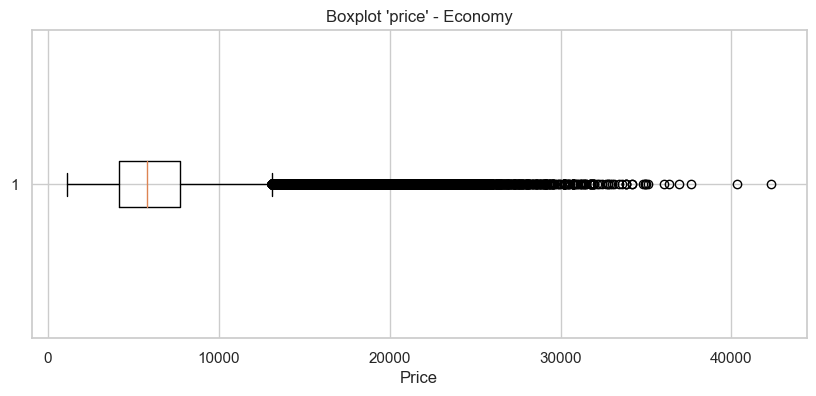

In [30]:
# Boxplot de 'price' para 'economy'

plt.figure(figsize=(10, 4))
plt.boxplot(df1["price"], vert=False)
plt.title("Boxplot 'price' - Economy")
plt.xlabel("Price")
plt.show()

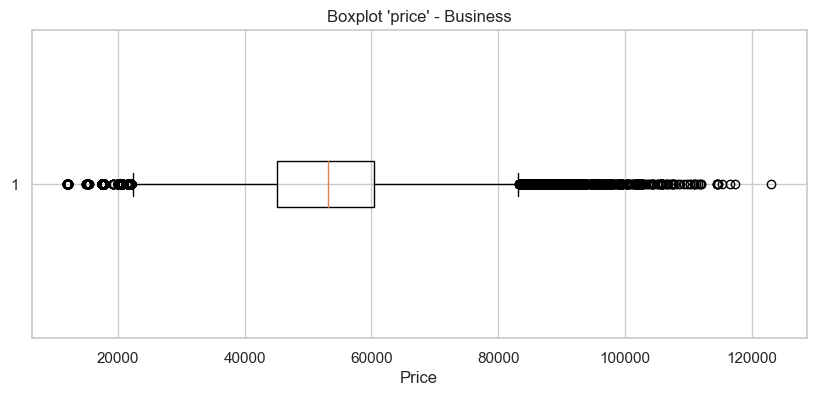

In [31]:
# Boxplot de 'price' para 'business'

plt.figure(figsize=(10, 4))
plt.boxplot(df2f["price"], vert=False)
plt.title("Boxplot 'price' - Business")
plt.xlabel("Price")
plt.show()

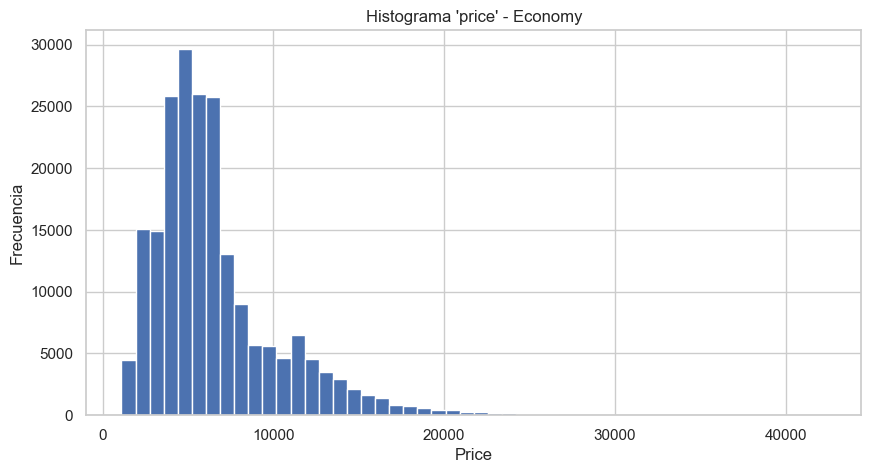

In [32]:
# Histograma 'price' para 'economy'

plt.figure(figsize=(10, 5))
plt.hist(df1["price"], bins=50)
plt.title("Histograma 'price' - Economy")
plt.xlabel("Price")
plt.ylabel("Frecuencia")
plt.show()

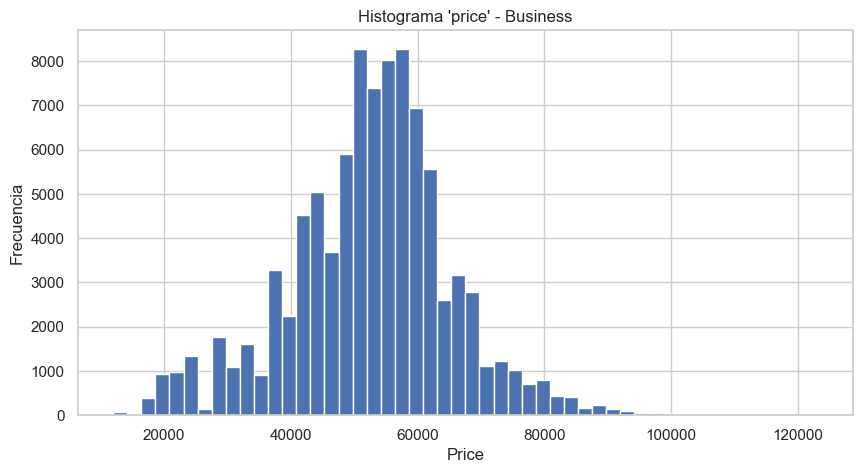

In [33]:
# Histograma 'price' para 'business'

plt.figure(figsize=(10, 5))
plt.hist(df2f["price"], bins=50)
plt.title("Histograma 'price' - Business")
plt.xlabel("Price")
plt.ylabel("Frecuencia")
plt.show()

##### Interpretación:
- En ambos casos, los outliers parecieran seguir un comportamiento normal para el negocio, es decir, existe un porcentaje (algo menor) de datos con valores altos y muy altos, lo que puede obedecer a precios de veulos en temporadas altas de vacaciones, fechas especificas y/o destinos especiales. 
- Al parecer, no representan errores de datos, por lo tanto, eliminar estos registros reduciría la capacidad del modelo para aprender precios extremos
- Decisión: Se conservan los outliers detectados.

#### F. Cardinalidad (valores nulos)

In [36]:
# Cardinalidad para 'economy' 

cardinality_economy = df1.nunique().sort_values(ascending=False)
cardinality_economy

price         9819
num_code      1254
time_taken     480
arr_time       266
dep_time       251
date            49
airline          8
ch_code          8
from             6
to               6
stop             3
dtype: int64

In [37]:
# Cardinalidad para 'business' 

cardinality_business = df2f.nunique().sort_values(ascending=False)
cardinality_business

price         2358
time_taken     373
num_code       264
arr_time       176
dep_time       166
date            49
from             6
to               6
stop             3
airline          2
ch_code          2
dtype: int64

#### Análisis:
1. Variable objetivo ('price'): Alta cardinalidad en ambos datasets, es esperable ya que es una variable continua, refleja variabilidad del mercado ==> No se aplica ningún tratamiento de cardinalidad a la variable objetivo.
2. Variables con baja cardinalidad: from y to (6), airline y ch_code (2–8), stop (25–37) ==> se aplicará One-Hot Encodind
3. Variables con cardinalidad media: date (49) y stop (25–37) ==> separar variables (mes, día, tipos de dias (fin de semana, laboral, etc).
4. Variables con alta cardinalidad (>166):
   - num_code => evaluar eliminación o uso como identificador
   - time_taken => cambiar a numérica,
   - dep_time => cambiar a horaria
   - arr_time => cambiar a horaria

### 3. Análisis exploratorio (análisis univariado y bivariado)

#### EDA UNIVARIADO (análisis por variable)

#### 1. Variable objetivo ´price'

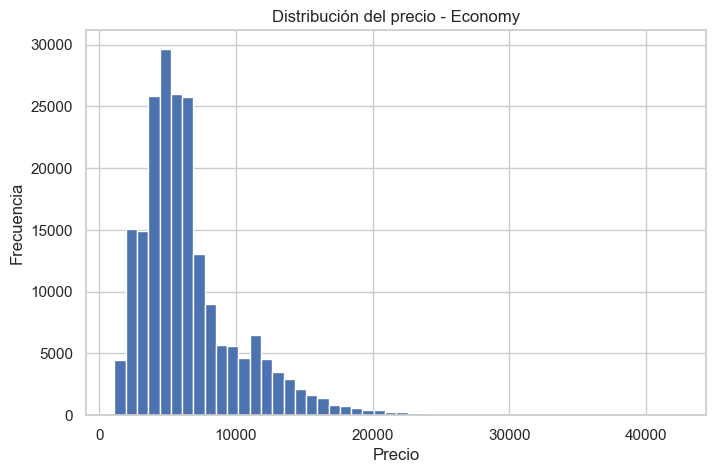

In [42]:
# Histograma 'economy'

plt.figure(figsize=(8,5))
plt.hist(df1["price"], bins=50)
plt.title("Distribución del precio - Economy")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

#### Observaciones 'economy' – Distribución del precio
- Distribución asimétrica a la derecha (cola larga).
- Alta concentración de precios en el rango bajo–medio.
- Pocos vuelos con precios muy altos (outliers superiores).

Entonces:
- El precio no sigue una distribución normal.
- Modelos sensibles a outliers pueden verse afectados.

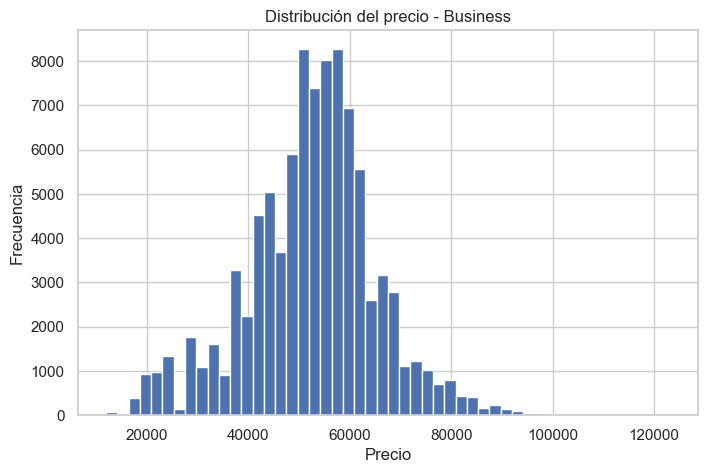

In [44]:
# Histograma 'business'

plt.figure(figsize=(8,5))
plt.hist(df2f["price"], bins=50)
plt.title("Distribución del precio - Business")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

#### Observaciones 'business' – Distribución del precio
- Distribución más centrada, aunque también asimétrica.
- Precios claramente más altos que economy.
- Mayor dispersión absoluta de precios.

Entonces:
- Los vuelos business tienen una estructura de precios distinta.
- Menor volumen, pero precios mucho más elevados.
- La variabilidad sigue siendo relevante, pero el rango es mayor.

#### 2. Variable 'stop': vuelos con escalas

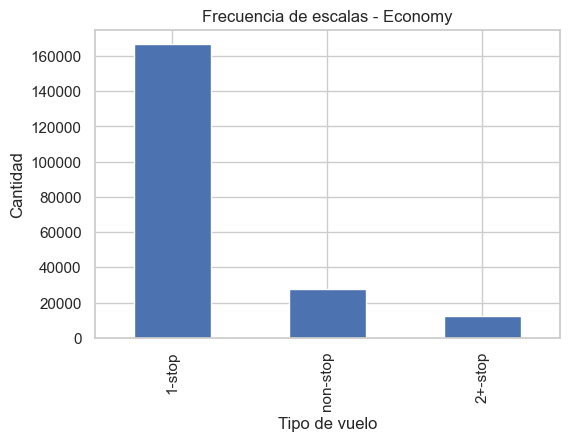

In [47]:
# Histograma 'economy'

df1["stop"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Frecuencia de escalas - Economy")
plt.xlabel("Tipo de vuelo")
plt.ylabel("Cantidad")
plt.show()

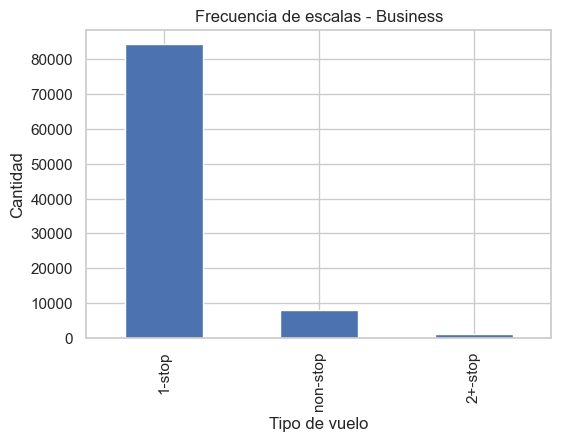

In [48]:
# Histograma 'business'

df2f["stop"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Frecuencia de escalas - Business")
plt.xlabel("Tipo de vuelo")
plt.ylabel("Cantidad")
plt.show()

#### 3. Variable 'time_taken': Distribución de duración del vuelo

In [50]:
df1["time_taken"].value_counts().head(10) # 'economy'

time_taken
02h 10m    3081
02h 15m    2912
02h 45m    2006
02h 05m    1969
02h 50m    1723
02h 20m    1537
08h 00m    1485
07h 35m    1443
12h 00m    1432
06h 40m    1420
Name: count, dtype: int64

In [51]:
df2f["time_taken"].value_counts().head(10)  # 'business'

time_taken
02h 10m    1161
02h 15m    1124
02h 45m     873
12h 25m     838
12h 05m     822
12h 00m     792
02h 05m     786
11h 10m     767
11h 25m     728
13h 00m     722
Name: count, dtype: int64

In [52]:
# Conversión de variable 'time_taken' a minutos (variable numérica continua)=> 'duration_min'

def time_taken_to_minutes(df, col="time_taken"):
    df = df.copy()
    
    hours = df[col].str.extract(r"(\d+)h").astype(int)
    minutes = df[col].str.extract(r"(\d+)m").astype(int)
    
    df["duration_min"] = hours[0] * 60 + minutes[0]
    
    return df

In [53]:
df1 = time_taken_to_minutes(df1)  # 'economy'
df1[["time_taken", "duration_min"]].head()

,time_taken,duration_min
0,02h 10m,130
1,02h 20m,140
2,02h 10m,130
3,02h 15m,135
4,02h 20m,140


In [54]:
df2f = time_taken_to_minutes(df2f)  # 'business'
df2f[["time_taken", "duration_min"]].head()

,time_taken,duration_min
0,02h 00m,120
1,02h 15m,135
2,24h 45m,1485
3,26h 30m,1590
4,06h 40m,400


#### EDA BIVARIADO (relación entre dos variables)

#### 1. 'price' vs 'stop'

<Figure size 700x500 with 0 Axes>

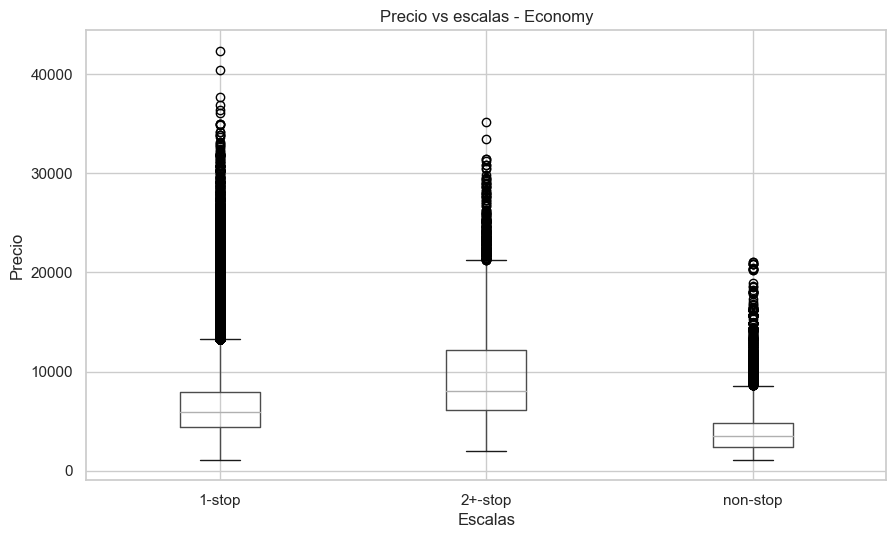

In [57]:
# 'economy'

plt.figure(figsize=(7,5))
df1.boxplot(column="price", by="stop") 
plt.title("Precio vs escalas - Economy")
plt.suptitle("")
plt.xlabel("Escalas")
plt.ylabel("Precio")
plt.show()

<Figure size 700x500 with 0 Axes>

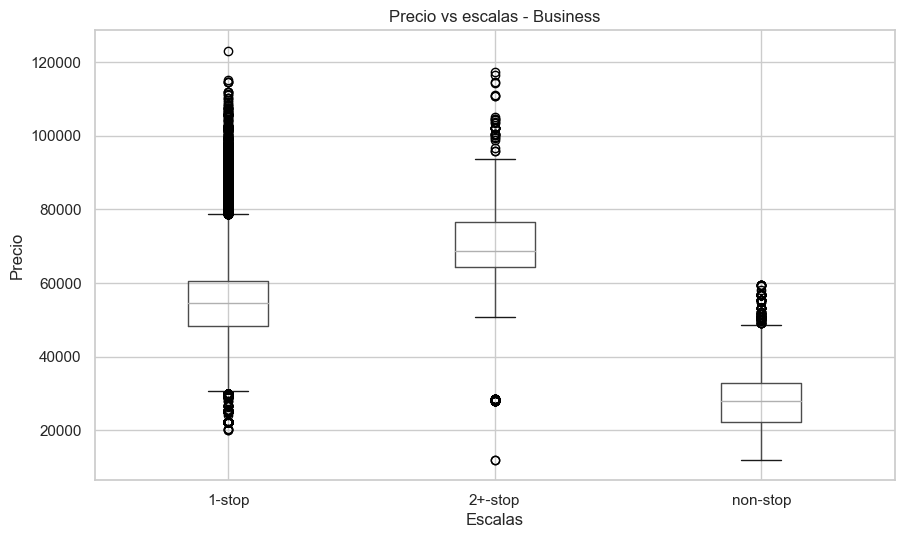

In [58]:
# 'business'

plt.figure(figsize=(7,5))
df2f.boxplot(column="price", by="stop")
plt.title("Precio vs escalas - Business")
plt.suptitle("")
plt.xlabel("Escalas")
plt.ylabel("Precio")
plt.show()

#### Observaciones:
- Para ambos data, más escalas están asociadas a precios más altos, no más bajos.
- Esto puede reflejar: rutas más largas, trayectos menos directos, o mayor tiempo total de viaje.
- Comportamiento muy parecido entre ambos data
- Existe relación (positiva) entre stop y price, stop es una variable predictora relevante

#### 2. 'price' vs. 'duration_min'

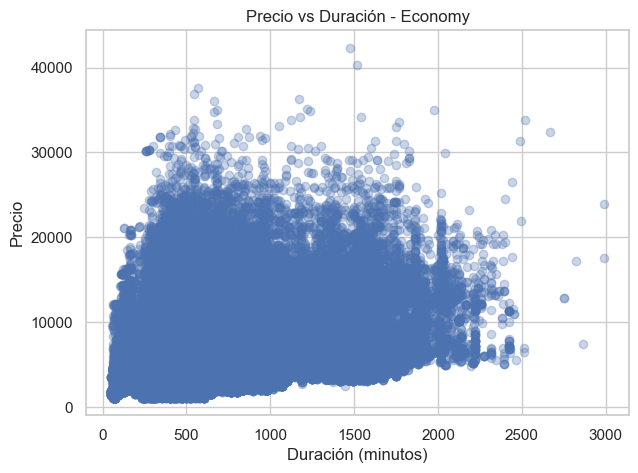

In [61]:
# 'economy'

plt.figure(figsize=(7,5))
plt.scatter(df1["duration_min"], df1["price"], alpha=0.3)
plt.title("Precio vs Duración - Economy")
plt.xlabel("Duración (minutos)")
plt.ylabel("Precio")
plt.show()

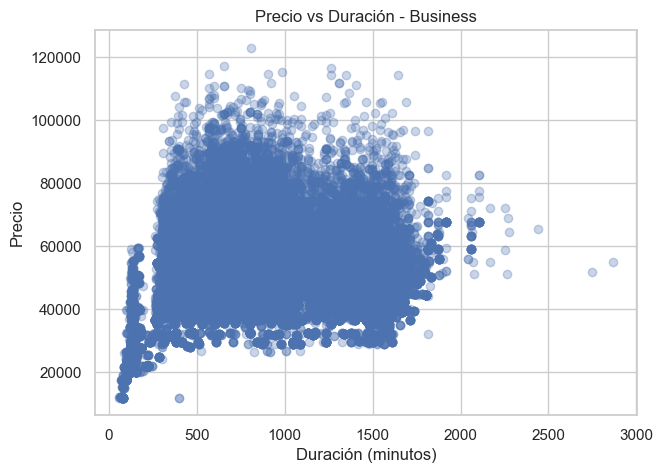

In [62]:
# 'business

plt.figure(figsize=(7,5))
plt.scatter(df2f["duration_min"], df2f["price"], alpha=0.3)
plt.title("Precio vs Duración - Business")
plt.xlabel("Duración (minutos)")
plt.ylabel("Precio")
plt.show()

#### Conclusiones:
- La duración del vuelo sí está relacionada con el precio
- La relación no es lineal 
- A mayor duración, mayor variabilidad de precios
- 'duration_min- es una variable predictora relevante

#### 3. 'price' vs 'airline'

<Figure size 900x500 with 0 Axes>

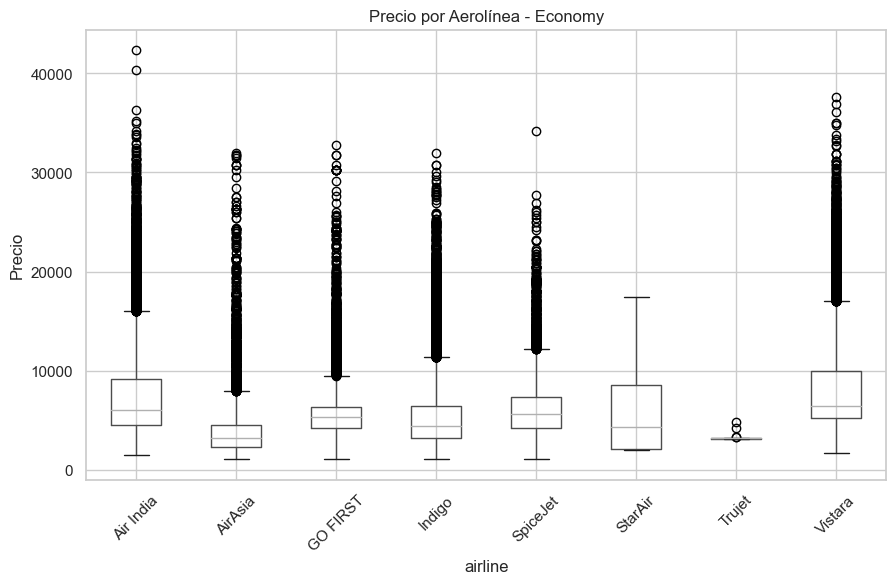

In [65]:
# 'economy'

plt.figure(figsize=(9,5))
df1.boxplot(column="price", by="airline", rot=45)
plt.title("Precio por Aerolínea - Economy")
plt.suptitle("")
plt.ylabel("Precio")
plt.show()

<Figure size 600x500 with 0 Axes>

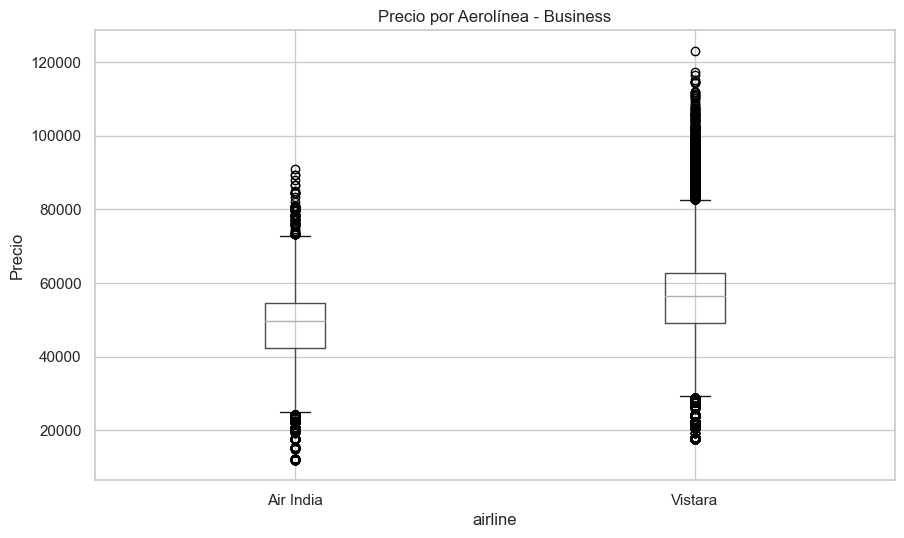

In [66]:
# 'business'

plt.figure(figsize=(6,5))
df2f.boxplot(column="price", by="airline")
plt.title("Precio por Aerolínea - Business")
plt.suptitle("")
plt.ylabel("Precio")
plt.show()

#### Conclusiones:
- La aerolínea influye en el precio del vuelo, en 'business' es más claro.
- Para 'economy', cada aerolínea tiene una estrategia de precios distinta.
- Una misma aerolínea puede ofrecer vuelos baratos y caros, dependiendo de ruta, fecha y duración.
- Para 'business' solo aparecen dos aerolíneas, una aerolínea tiene mediana de precio más alta y mayor rango de precios.
  
==> airline debe incluirse en el modelo, al ser categórica requiere encoding.

#### 4. 'price' vs. 'date' (día de la semana)

In [69]:
# Preparación 'date': cambiar a día de la semana

df1["day_of_week"] = df1["date"].dt.day_name()
df2f["day_of_week"] = df2f["date"].dt.day_name()

<Figure size 900x500 with 0 Axes>

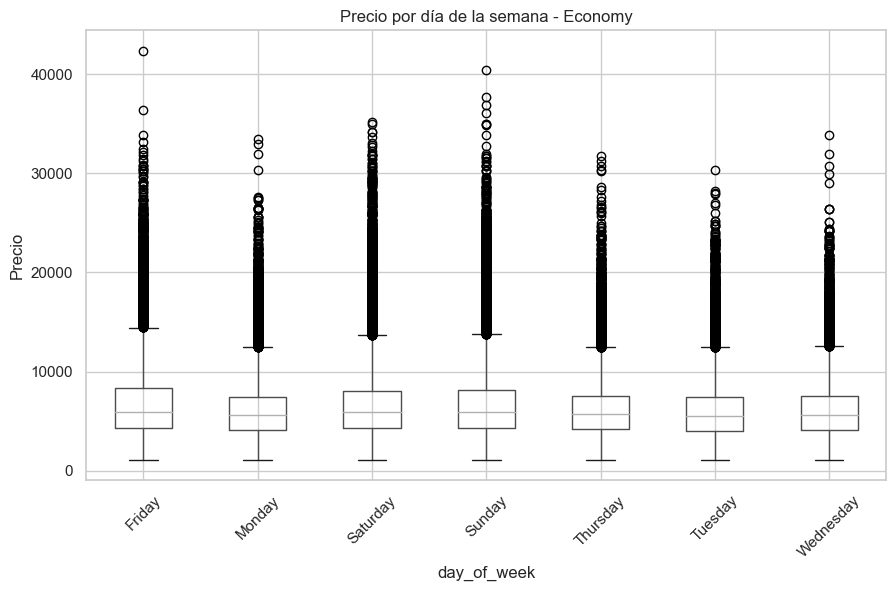

In [70]:
# 'economy'

plt.figure(figsize=(9,5))
df1.boxplot(column="price", by="day_of_week", rot=45)
plt.title("Precio por día de la semana - Economy")
plt.suptitle("")
plt.ylabel("Precio")
plt.show()

<Figure size 900x500 with 0 Axes>

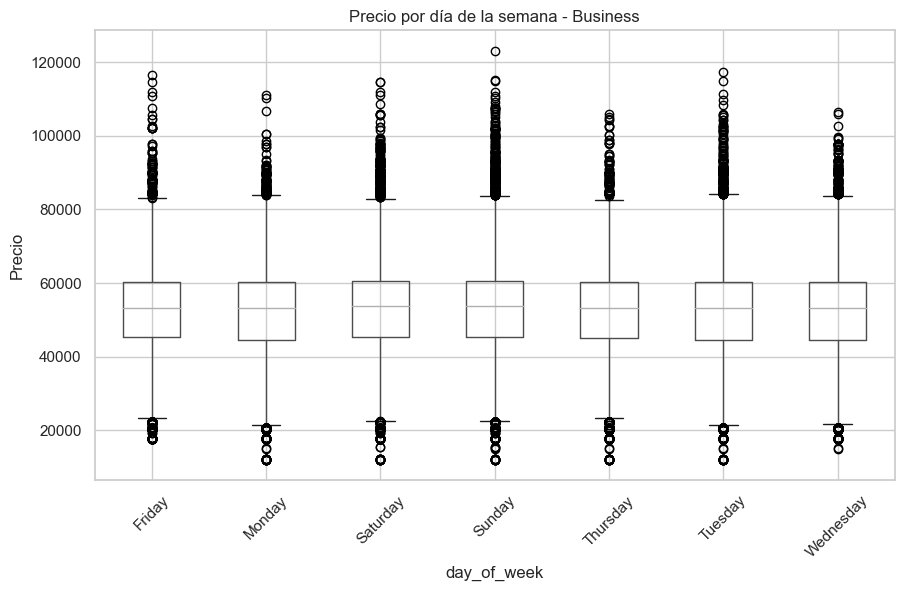

In [71]:
# 'business'

plt.figure(figsize=(9,5))
df2f.boxplot(column="price", by="day_of_week", rot=45)
plt.title("Precio por día de la semana - Business")
plt.suptitle("")
plt.ylabel("Precio")
plt.show()

#### Conclusiones:

- El día de la semana aporta información débil, variable secundaria
- No existe un patrón semanal relevante de precios

#### Por lo tanto:

- El precio está fuertemente asociado al número de escalas ('stop') ==>  variable predictora importante
- Variable 'duraction_min' tiene una relación positiva con el precio ==> variable predictora importante
- Variable 'airline' influye de manera importante en el precio ==> variable predictora importante
- Variable 'day_of_week' tiene un impacto limitado en el precio ==> variable secundaria


### 4. Análisis de Correlaciones 

#### - Correlación de Pearson

In [75]:
# Variables numéricas

num_cols = [
    "price",
    "duration_min",
    "num_code"
]

df1_num = df1[num_cols].copy()
df2_num = df2f[num_cols].copy()

In [76]:
corr_pearson_economy = df1_num.corr(method="pearson")
corr_pearson_economy

,price,duration_min,num_code
price,1.000000,0.288620,-0.090916
duration_min,0.288620,1.000000,-0.124905
num_code,-0.090916,-0.124905,1.000000


In [77]:
corr_pearson_business = df2_num.corr(method="pearson")
corr_pearson_business

,price,duration_min,num_code
price,1.000000,0.242729,0.221424
duration_min,0.242729,1.000000,-0.081873
num_code,0.221424,-0.081873,1.000000


#### - Correlación de Spearman

In [79]:
corr_spearman_economy = df1_num.corr(method="spearman")
corr_spearman_economy

,price,duration_min,num_code
price,1.000000,0.358233,-0.060705
duration_min,0.358233,1.000000,-0.090065
num_code,-0.060705,-0.090065,1.000000


In [80]:
corr_spearman_business = df2_num.corr(method="spearman")
corr_spearman_business

,price,duration_min,num_code
price,1.000000,0.164790,0.211198
duration_min,0.164790,1.000000,-0.078093
num_code,0.211198,-0.078093,1.000000


#### - Correlación directa con la variable objetivo

In [82]:
corr_price_economy = corr_spearman_economy["price"].sort_values(ascending=False)
corr_price_economy

price           1.000000
duration_min    0.358233
num_code       -0.060705
Name: price, dtype: float64

In [83]:
corr_price_business = corr_spearman_business["price"].sort_values(ascending=False)
corr_price_business

price           1.000000
num_code        0.211198
duration_min    0.164790
Name: price, dtype: float64

#### Conclusiones:

1. No aparecen correlaciones altas (> 0.7), el precio depende de muchas variables.
2. 'duration_min' es una variable predictora a considerar, ya que tiene relación positiva con el precio del vuelo.
3. 'num_code' no debe usarse como predictor, ya que no se observa una relación real y estructurada con el precio.

### Selección de variables

#### Variables más importantes para la predicción del precio:

1. Alta relevancia:
   - duration_min
   - stop
   - airline 
2. Relevancia media:
   - day_of_week
4. Baja o nula relevancia:
   - num_code

### 5. Transformaciones para realizar el modelamiento 

#### Preparación de los dataset: 

1. Convertir 'stop' => stop_num: texto
2. Convertir 'dep_time' y 'arr_time' => 'dep_hour' y 'arr_hour'
3. Convertir 'date' => 'day_of_week' => 'is_weekend': efecto temporal
4. Eliminar variables no relevantes/ transformadas ("num_code", "time_taken", "dep_time", "arr_time", "date", "ch_code", "stop")

In [89]:
# 1. Crear número de escalas ('stop' => 'stop_num')

def stop_to_numeric(df):
    df = df.copy()
    df["stop_num"] = (
        df["stop"]
        .str.extract(r"(\d+)")
        .astype(float)
        .fillna(0)
        .astype(int)
    )
    return df

df1 = stop_to_numeric(df1)
df2f = stop_to_numeric(df2f)

In [90]:
# 2. Tranformar 'dep_time' y 'arr_time': hora de salida y llegada

df1["dep_hour"] = pd.to_datetime(df1["dep_time"], format="%H:%M:%S").dt.hour
df1["arr_hour"] = pd.to_datetime(df1["arr_time"], format="%H:%M:%S").dt.hour

df2f["dep_hour"] = pd.to_datetime(df2f["dep_time"], format="%H:%M:%S").dt.hour
df2f["arr_hour"] = pd.to_datetime(df2f["arr_time"], format="%H:%M:%S").dt.hour

In [91]:
# 3. Crear variables temporales desde 'date'

df1["day_of_week"] = df1["date"].dt.dayofweek   # 0 = lunes
df2f["day_of_week"] = df2f["date"].dt.dayofweek

df1["is_weekend"] = df1["day_of_week"].isin([5,6]).astype(int)
df2f["is_weekend"] = df2f["day_of_week"].isin([5,6]).astype(int)

In [92]:
# 4. Eliminar columnas no relevantes y redundantes ('ch_code')

cols_to_drop = ["num_code", "time_taken", "dep_time", "arr_time", "date", "ch_code", "stop"]

df1 = df1.drop(columns=cols_to_drop)
df2f = df2f.drop(columns=cols_to_drop)

In [93]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206770 entries, 0 to 206773
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   airline       206770 non-null  object
 1   from          206770 non-null  object
 2   to            206770 non-null  object
 3   price         206770 non-null  int64 
 4   duration_min  206770 non-null  int32 
 5   day_of_week   206770 non-null  int32 
 6   stop_num      206770 non-null  int32 
 7   dep_hour      206770 non-null  int32 
 8   arr_hour      206770 non-null  int32 
 9   is_weekend    206770 non-null  int32 
dtypes: int32(6), int64(1), object(3)
memory usage: 12.6+ MB


In [94]:
df2f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   airline       93487 non-null  object
 1   from          93487 non-null  object
 2   to            93487 non-null  object
 3   price         93487 non-null  int64 
 4   duration_min  93487 non-null  int32 
 5   day_of_week   93487 non-null  int32 
 6   stop_num      93487 non-null  int32 
 7   dep_hour      93487 non-null  int32 
 8   arr_hour      93487 non-null  int32 
 9   is_weekend    93487 non-null  int32 
dtypes: int32(6), int64(1), object(3)
memory usage: 5.0+ MB


### 6. Función para entregar un dataset limpio y procesado 

In [96]:
def preprocess_flights(df: pd.DataFrame, drop_stop_text: bool = True) -> pd.DataFrame:
    
    df = df.copy()

    # date a datetime
    if "date" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["date"]):
        df["date"] = pd.to_datetime(df["date"], errors="coerce")

    # price a numérico 
    if "price" in df.columns and not pd.api.types.is_numeric_dtype(df["price"]):
        df["price"] = pd.to_numeric(df["price"], errors="coerce")

    # stop: limpieza de texto 
    if "stop" in df.columns:
        df["stop"] = (
            df["stop"]
            .astype(str)
            .str.replace(r"\s+", " ", regex=True)     # quita \n \t y espacios múltiples
            .str.strip()
            .str.replace(r"\s+Via.*$", "", regex=True) # quita "Via ..."
        )

    # time_taken: filtrar inválidos y convertir a minutos
    if "time_taken" in df.columns:
        df = df[df["time_taken"].astype(str).str.match(r"^\d+h \d+m$")].copy()
        h = df["time_taken"].str.extract(r"(\d+)h").astype(int)[0]
        m = df["time_taken"].str.extract(r"(\d+)m").astype(int)[0]
        df["duration_min"] = h * 60 + m

    # stop_num (0,1,2...)
    if "stop" in df.columns:
        df["stop_num"] = (
            df["stop"]
            .str.extract(r"(\d+)")
            .astype(float)
            .fillna(0)
            .astype(int)
        )

    # Variables derivadas de hora
    if "dep_time" in df.columns:
        df["dep_hour"] = pd.to_datetime(df["dep_time"], format="%H:%M:%S", errors="coerce").dt.hour
    if "arr_time" in df.columns:
        df["arr_hour"] = pd.to_datetime(df["arr_time"], format="%H:%M:%S", errors="coerce").dt.hour

    # Variables derivadas de fecha
    if "date" in df.columns:
        df["day_of_week"] = df["date"].dt.dayofweek
        df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

    # Eliminar columnas no relevantes 
    df = df.drop(columns=["num_code", "ch_code"], errors="ignore")

    # Eliminar columnas ya reemplazadas
    df = df.drop(columns=["time_taken", "dep_time", "arr_time", "date"], errors="ignore")

    # Mantener stop_num y eliminar stop
    if drop_stop_text:
        df = df.drop(columns=["stop"], errors="ignore")

    # Limpieza final: eliminar filas con NaN críticos
    required = [c for c in ["price", "duration_min", "stop_num"] if c in df.columns]
    if required:
        df = df.dropna(subset=required)

    return df

### 7. Selección de 3 modelos / entrenamiento y prueba

Para el desarrollo del modelo concatenaré ambos dataset.
El análisis de los datos los hice manteniendo ambos dataset separados, ya que consideré más fácil el entendimiento de los datos, observar sus comportamientods para luego poder comparar ambos data, identificar los distintos patrones.

In [99]:
# Concatenar dataset, con variable indicadora de clase

df1_proc = preprocess_flights(df1, drop_stop_text=True)  # economy
df2_proc = preprocess_flights(df2f, drop_stop_text=True)  # business

In [100]:
print("df1_proc:", df1_proc.shape)
print("df2_proc:", df2_proc.shape)

print(df1_proc.dtypes)
print(df2_proc.dtypes)

df1_proc: (206770, 10)
df2_proc: (93487, 10)
airline         object
from            object
to              object
price            int64
duration_min     int32
day_of_week      int32
stop_num         int32
dep_hour         int32
arr_hour         int32
is_weekend       int32
dtype: object
airline         object
from            object
to              object
price            int64
duration_min     int32
day_of_week      int32
stop_num         int32
dep_hour         int32
arr_hour         int32
is_weekend       int32
dtype: object


In [101]:
df1_proc.head()

,airline,from,to,price,duration_min,day_of_week,stop_num,dep_hour,arr_hour,is_weekend
0,SpiceJet,Delhi,Mumbai,5953,130,4,0,18,21,0
1,SpiceJet,Delhi,Mumbai,5953,140,4,0,6,8,0
2,AirAsia,Delhi,Mumbai,5956,130,4,0,4,6,0
3,Vistara,Delhi,Mumbai,5955,135,4,0,10,12,0
4,Vistara,Delhi,Mumbai,5955,140,4,0,8,11,0


In [102]:
df2_proc.head()

,airline,from,to,price,duration_min,day_of_week,stop_num,dep_hour,arr_hour,is_weekend
0,Air India,Delhi,Mumbai,25612,120,4,0,18,20,0
1,Air India,Delhi,Mumbai,25612,135,4,0,19,21,0
2,Air India,Delhi,Mumbai,42220,1485,4,1,20,20,0
3,Air India,Delhi,Mumbai,44450,1590,4,1,21,23,0
4,Air India,Delhi,Mumbai,46690,400,4,1,17,23,0


In [103]:
df1_proc["flight_class"] = 0  # economy
df2_proc["flight_class"] = 1  # business

df_all = pd.concat([df1_proc, df2_proc], axis=0, ignore_index=True)

print("df_all shape:", df_all.shape)
print(df_all["flight_class"].value_counts())

df_all shape: (300257, 11)
flight_class
0    206770
1     93487
Name: count, dtype: int64


In [104]:
# Separar X e y

X = df_all.drop(columns=["price"])
y = df_all["price"]

In [105]:
# Definir features numéricas y categóricas

num_features = [
    "duration_min",
    "stop_num",
    "dep_hour",
    "arr_hour",
    "day_of_week",
    "is_weekend",
    "flight_class"
]

cat_features = ["airline", "from", "to"]

In [106]:
# Train/Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [107]:
# Preprocesamiento + Pipelines

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

#### Modelos a entrenar :

El modelo debe considerar todas estas condiciones:
- variable continua
- regresión supervisada
- variables numéricas y categóricas
- relaciones no lineales
- dataset grande (>300k filas)

1. Regresion Lineal: modelo simple, rápido, interpretable y básico ==> baseline
2. Random Forest: ideal para relaciones no lineales, muchos outliers y muchas categorías
3. Gradient Boosting: modelo más robusto, de mayor performance esperada


In [109]:
# Entrenar los modelos seleccionados

%pip install xgboost
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

Note: you may need to restart the kernel to use updated packages.


In [110]:
# Definir pipelines

pipe_lr = Pipeline([                   # Regresion Lineal
    ("prep", preprocessor),
    ("model", LinearRegression())
])

pipe_rf = Pipeline([                  # Random Forest
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=1
    ))
])

pipe_xgb = Pipeline([                 # XGBoost
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        objective="reg:squarederror"
    ))
])

In [111]:
# Entrenar modelos

models = {
    "Linear Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb
}

for name, model in models.items():
    print(f"Entrenando {name}...")
    model.fit(X_train, y_train)
    print("OK Modelo entrenado")

Entrenando Linear Regression...
OK Modelo entrenado
Entrenando Random Forest...
OK Modelo entrenado
Entrenando XGBoost...
OK Modelo entrenado


### 8.  Grilla de hiperparametros 

In [113]:
# Optimización de hiperparámetros (RF y XGBoost)
# Mantenemos Linear Regression como baseline

from sklearn.model_selection import GridSearchCV

scoring = "neg_mean_absolute_error"
cv_folds = 3

In [ ]:
# Tuning con muestra más pequeña del train 

from sklearn.model_selection import train_test_split

X_train_s, _, y_train_s, _ = train_test_split(       
    X_train,
    y_train,
    train_size=20000,   
    random_state=42
)
print("Tuning sample shape:", X_train_s.shape)


In [114]:
# GridSearchCV — Random Forest

param_grid_rf = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 20, 30],
    "model__min_samples_leaf": [1, 2],
    "model__min_samples_split": [2, 5],
    "model__max_features": ["sqrt", "log2"]
}

# Ejecutar búsqueda

grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1,
    verbose=2,
    pre_dispatch=1
)

grid_rf.fit(X_train_s, y_train_s)                       # con la muestra pequeña

print("OK RF best params:", grid_rf.best_params_)
print("OK RF best CV MAE:", -grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   8.4s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   9.1s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   8.4s
[CV] END model__max_depth=None, model__min_samples_leaf=2, model__n_estimators=200; total time=   7.0s
[CV] END model__max_depth=None, model__min_samples_leaf=2, model__n_estimators=200; total time=   6.9s
[CV] END model__max_depth=None, model__min_samples_leaf=2, model__n_estimators=200; total time=   7.1s
[CV] END model__max_depth=20, model__min_samples_leaf=1, model__n_estimators=200; total time=   7.6s
[CV] END model__max_depth=20, model__min_samples_leaf=1, model__n_estimators=200; total time=   7.6s
[CV] END model__max_depth=20, model__min_samples_leaf=1, model__n_estimators=200; total time=   7.9s
[CV] END model__max

In [197]:
# Reentrenar con train completo

best_rf.fit(X_train, y_train)
print("OK RF reentrenado con train completo")

OK RF reentrenado con train completo


In [199]:
# GridSearch - XGBoost

param_grid_xgb = {                                # Grilla acotada 
    "model__n_estimators": [300, 600],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1, 10]   
}

grid_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=1,          
    verbose=2,
    pre_dispatch=1
)

grid_xgb.fit(X_train_s, y_train_s)

print("\nOK XGB best params:", grid_xgb.best_params_)
print("OK XGB best CV MAE:", -grid_xgb.best_score_)

best_xgb = grid_xgb.best_estimator_

Fitting 3 folds for each of 96 candidates, totalling 288 fits
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=300, model__reg_lambda=1, model__subsample=0.8; total time=   0.3s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=300, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=300, model__reg_lambda=1, model__subsample=0.8; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=300, model__reg_lambda=1, model__subsample=1.0; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__n_estimators=300, model__reg_lambda=1, model__subsample=1.0; total time=   0.1s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_de

In [201]:
# Reentrenar con train completo

best_xgb.fit(X_train, y_train)
print("OK XGBoost reentrenado con train completo")


OK XGBoost reentrenado con train completo


In [203]:
# Resultados finales de los 3 modelos 

best_models = {
    "Linear Regression (baseline)": pipe_lr,  
    "Random Forest (tuned)": best_rf,
    "XGBoost (tuned)": best_xgb
}

print("\nOK Modelos finales listos para evaluación (Punto 9).")
for k in best_models:
    print("-", k)


OK Modelos finales listos para evaluación (Punto 9).
- Linear Regression (baseline)
- Random Forest (tuned)
- XGBoost (tuned)


###  9. Métricas 

In [205]:
# Métricas "MAE", "RMSE", "R2"

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, rmse, r2])

In [207]:
# Comparativo (LR baseline)

results_df = pd.DataFrame(
    results,
    columns=["Modelo", "MAE", "RMSE", "R2"]
)

results_df = results_df.sort_values("MAE")

results_df

,Modelo,MAE,RMSE,R2
1,Random Forest (tuned),2315.966160,3810.871353,0.971940
2,XGBoost (tuned),2434.910309,3682.153254,0.973804
0,Linear Regression (baseline),4801.362070,7073.432844,0.903329


**Observaciones:**
- Mejor MAE => RF (reduce el error app 50% respecto al baseline)
- Mejor RMSE => XGB (comete menos errores extremos, es más estable para outliers)
- Mejor R2 => XGB

==> El mejor modelo RF ya que presenta menor MAE (error promedio menor => mayor precisión)

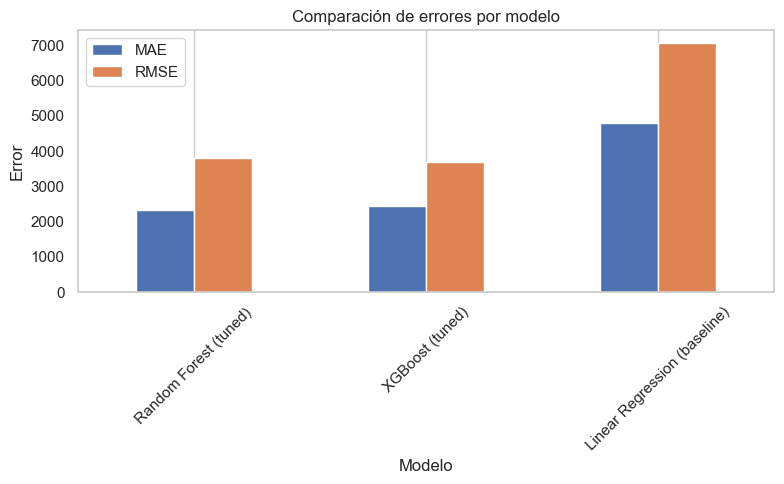

In [209]:
# Gráfico comparativo de métricas

results_df.set_index("Modelo")[["MAE", "RMSE"]].plot(kind="bar", figsize=(8,5))

plt.title("Comparación de errores por modelo")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Observaciones:**
- Linear Regression: barras mucho más altas => peor desempeño
- Random Forest: menor MAE => mejor error promedio
- XGBoost: menor RMSE => menos errores grandes

==> Los modelos de árboles superan ampliamente a la regresión lineal

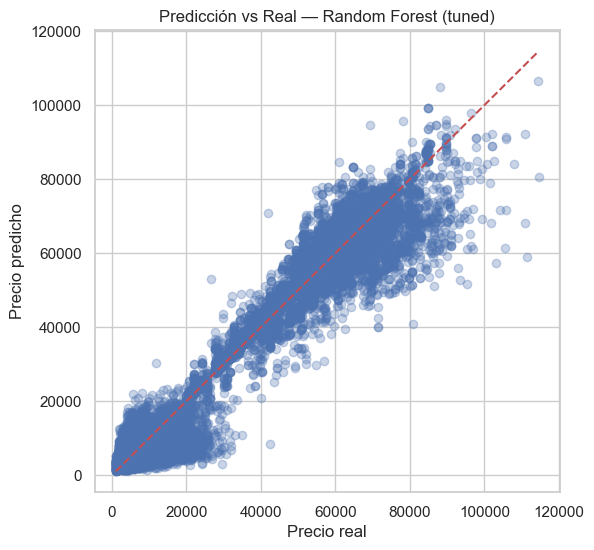

In [211]:
# Predicción vs valores reales 

best_name = results_df.iloc[0]["Modelo"]
best_model = best_models[best_name]

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title(f"Predicción vs Real — {best_name}")
plt.show()

**Observaciones:**
- Se observan puntos bien alineados en diagonal (línea roja => predicción perfecta) => modelo ajusta bien
- Poca dispersión => errores pequeños

### 10. Conclusión final 

El objetivo del proyecto fue desarrollar un modelo de Machine Learning capaz de predecir el precio de pasajes aéreos a partir de variables operacionales del vuelo, tales como aerolínea, duración, número de escalas, horarios y día de la semana.

Durante el proceso se aplicó la metodología CRISP-DM, abordando etapas de comprensión del negocio, calidad de datos, análisis exploratorio, ingeniería de características, modelamiento y evaluación.

El análisis exploratorio permitió identificar que los precios presentan distribuciones "raras" con presencia de outliers, que la duración del vuelo y el número de escalas influyen directamente en el precio, existen diferencias claras entre clases (economy vs business), y que las relaciones entre variables son no lineales.

Tras el preprocesamiento y la creación de nuevas variables (duración en minutos, número de escalas, día de la semana, horario, fin de semana, etc.), se entrenaron tres modelos: Regresión Lineal (baseline), Random Forest y XGBoost.

Los resultados obtenidos en el conjunto de prueba fueron:
- Random Forest: MAE = 2.316 => el mejor
- XGBoost: MAE = 2.435
- Linear Regression: MAE = 4.801

Los modelos basados en árboles redujeron el error promedio más de un 50% respecto al baseline (R2 = 0.97=> excelente capacidad predictiva).
En consecuencia, se selecciona Random Forest como modelo final, dado que minimiza el error promedio, métrica más relevante para estimación de precios.

**Próximos pasos:**
- Para implementar este modelo de manera productiva, quizás convenga agregar más variables (temporada, feriados, eventos, etc)
- Agregar datos históricos más amplios, años completos.
- Probar más modelos (ej Catboost)